In [1]:
import os
import time
# os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

# #使用 CPU 平台
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax
import jax.numpy as jnp
import jax.tree_util as jtu


from flax import linen as nn
from flax.training import train_state
from flax import serialization
from flax import traverse_util

import optax
import matplotlib.pyplot as plt

from model import *

key = jax.random.PRNGKey(0)
print(f"JAX device: {jax.devices()}")

JAX device: [CudaDevice(id=0)]


In [2]:
# config = ModelConfig(Dim=dim,
#                      l = jnp.array([0.2,0.2]),
#                      hidden_layers_BNN = 256,
#                      N_points = 64,
#                      N_basis = 512,
#                      N_z = 64,
#                      Sample_size = 128,
#                      function = 'Poisson',
#                      function_K = 0.014,
#                      remark='GP_02',)

# config.save(config.out_dir+config.remark+".pkl")
config = ModelConfig.load("./out/GP_R.pkl")
pod_modes = jnp.load(config.out_dir+config.remark+'pod_modes.npy')
config.Sample_size = 400
config.sigma_B = 3
config

Config loaded (Pickle): ./out/GP_R.pkl


ModelConfig(Dim=2, l=Array([[0.33333334, 0.33333334],
       [0.2       , 0.2       ],
       [0.14285715, 0.14285715]], dtype=float32), sigma=Array([[3., 3.],
       [5., 5.],
       [7., 7.]], dtype=float32), hidden_layers_BNN=256, N_basis=512, Sample_size=400, sigma_B=3, theta_size=128, BranchNet_features=[512, 512, 512, 512, 512], TrunkNet_features=[512, 512, 512, 512, 512], function='Poisson', function_K=0.01, remark='GP_R', out_dir='./out/')

In [3]:
# ======= 模块 =======
class MLP(nn.Module):
    dim: int
    hidden_dim: int

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(self.hidden_dim)(x)
        x = nn.gelu(x)
        x = nn.Dense(self.dim)(x)
        return x
        
class MLPEmbed(nn.Module):
    dim: int        # 输出维度（= Transformer dim）
    hidden_dim: int # 中间隐藏层维度

    @nn.compact
    def __call__(self, x):
        # x: [B, L, D_in]
        x = nn.Dense(self.hidden_dim)(x)
        x = nn.gelu(x)
        x = nn.Dense(self.dim)(x)  # 输出为 dim
        return x

        
class TransformerBlock(nn.Module):
    dim: int
    num_heads: int
    mlp_dim: int

    @nn.compact
    def __call__(self, x):
        x = x + nn.SelfAttention(num_heads=self.num_heads, qkv_features=self.dim)(nn.LayerNorm()(x))
        x = x + MLP(self.dim, self.mlp_dim)(nn.LayerNorm()(x))
        return x

class TransformerModel(nn.Module):
    dim: int
    num_heads: int
    mlp_dim: int
    num_layers: int
    out_dim: int
    max_len: int = 512

    @nn.compact
    def __call__(self, x, cond):
        B, L, _ = x.shape
        _, L2, _ = cond.shape
        L = L + L2
        
        # MLP 嵌入
        x = MLPEmbed(dim=self.dim, hidden_dim=self.dim * 2)(x)
        cond = MLPEmbed(dim=self.dim, hidden_dim=self.dim * 2)(cond)

        x = jnp.concatenate([x,cond],1)

        # 加位置编码
        pos_emb = self.param('pos_embedding', nn.initializers.normal(stddev=0.02), (1, self.max_len, self.dim))
        x = x + pos_emb[:, :L, :]

        # 多层 Transformer
        for _ in range(self.num_layers):
            x = TransformerBlock(self.dim, self.num_heads, self.mlp_dim)(x)

        x = nn.LayerNorm()(x)
        x = x.mean(axis=1)              # 聚合
        x = nn.Dense(self.out_dim)(x)   # 输出
        return x

In [4]:
class TrainState(train_state.TrainState):
    pass

@jax.jit
def train_step(state, x, cond, y):
    def loss_fn(params):
        pred = state.apply_fn(params, x, cond)
        loss = jnp.mean((pred - y) ** 2)
        return loss

    grad_fn = jax.value_and_grad(loss_fn)
    loss, grads = grad_fn(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss

In [5]:
seq_len = 32
cond_len = 32

theta = jnp.linspace(0,jnp.pi*2,config.theta_size,False)[...,None]
thetaP = jnp.linspace(0,jnp.pi*2,config.theta_size*6,False)[...,None]

G_func = BNN_sin

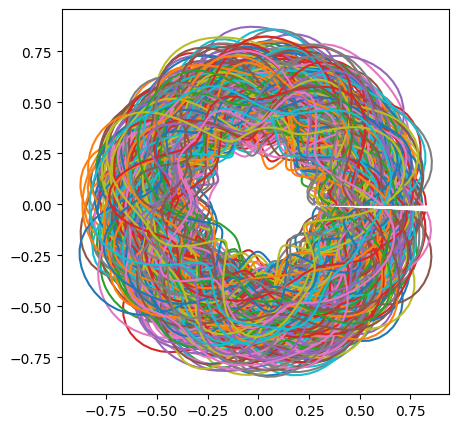

(400, 128, 2)

In [6]:
@jax.jit
def get_r(key, sigma_B, theta):
    r = BNN_boundary(key, sigma_B, theta,sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1)[...,0]
    return 0.45*jax.nn.tanh(0.3*r)+0.55

    

key, subkey = jax.random.split(key)
r = get_r(subkey,config.sigma_B,theta)

xx = jnp.cos(theta[...,0])*r
yy = jnp.sin(theta[...,0])*r
XY = jnp.stack([xx,yy],-1)


plt.figure(figsize=(5, 5))
Ns = 10
plt.plot(XY[:500,...,0].T,XY[:500,...,1].T)
plt.show()
XY.shape

In [7]:
Encoder = Model(config)
key, subkey = jax.random.split(key)
variables = Encoder.init(subkey, jnp.ones((1,pod_modes.shape[-1])), jnp.ones((1,config.Dim)))
Encoder_params = variables["params"]

# # 加载
with open(config.out_dir+config.remark+"Prior.msgpack", "rb") as f:
    Encoder_params = serialization.from_bytes(Encoder_params, f.read())  # 第二个参数是 bytes，返回结构匹配第一个参数的类型

In [8]:
@jax.jit
def sample(key, single_sigma, x_in = None):
    key, subkey = jax.random.split(key)
    r = get_r(subkey,config.sigma_B,theta)
    
    xx = jnp.cos(theta[...,0])*r
    yy = jnp.sin(theta[...,0])*r
    x_B = jnp.stack([xx,yy],-1)
    

    r0 = jnp.linspace(0.005,1,32)[:,None]**(0.8)
    xx0 = jnp.cos(theta[...,0])*r0
    yy0 = jnp.sin(theta[...,0])*r0
    x_0 = jnp.stack([xx0,yy0],-1).reshape(-1,2)[None,...].repeat(config.Sample_size,0)
    
    xx1 = jnp.cos(theta[...,0])*r0*r[:,None,:]
    yy1 = jnp.sin(theta[...,0])*r0*r[:,None,:]
    x_1 = jnp.stack([xx1,yy1],-1).reshape(config.Sample_size,-1,2)

    key, subkey = jax.random.split(key)
    u_B, _ = func(G_func(subkey, single_sigma, x_B, sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1), config.function_K, config.function)
    u_area, f_area = func(G_func(subkey, single_sigma, x_1, sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1), config.function_K, config.function)
    
    # k_u_area  = jnp.dot(u_area[...,0], pod_modes)
    # k_f_area  = jnp.dot(f_area[...,0], pod_modes)

    k_uin = Encoder.apply({"params": Encoder_params}, jnp.dot(u_area[...,0], pod_modes), method = Encoder.get_branch_net_output)
    k_fin = Encoder.apply({"params": Encoder_params}, jnp.dot(f_area[...,0], pod_modes), method = Encoder.get_branch_net_output)
    
    cond = jnp.concatenate([x_B,u_B],-1)
    
    cond = cond.reshape(cond.shape[0], cond_len, -1)
    k_fin = k_fin.reshape(k_fin.shape[0], seq_len, -1)

    
    return cond, k_fin, k_uin, u_area, f_area, x_0, x_1
    
@jax.jit
def Sample_list(key):
    # 1. 先收集所有样本
    samples = []
    for i in config.sigma:
        key, subkey = jax.random.split(key)
        res = sample(subkey, i)  # 返回 (x_B, x_0, x_1, u_B, u_area, f_area)
        samples.append(res)
    
    # 2. 使用 tree_map 一键拼接
    # *samples 会解包列表，tree_map 会把所有 tuple 对应位置的数组传给 lambda
    final_res = jtu.tree_map(lambda *args: jnp.concatenate(args, axis=0), *samples)
    
    return final_res

# @jax.jit
# def Sample_list(key):
    
#     key, subkey = jax.random.split(key)
#     single_sample = jax.random.choice(subkey, config.sigma)

#     # 1. 先收集所有样本
#     samples = []
#     for i in config.sigma:
#         key, subkey = jax.random.split(key)
#         res = sample(subkey, single_sample)  # 返回 (x_B, x_0, x_1, u_B, u_area, f_area)
#         samples.append(res)
    
#     # 2. 使用 tree_map 一键拼接
#     # *samples 会解包列表，tree_map 会把所有 tuple 对应位置的数组传给 lambda
#     final_res = jtu.tree_map(lambda *args: jnp.concatenate(args, axis=0), *samples)
    
#     return final_res

In [9]:
key, subkey = jax.random.split(key)
cond, k_fin, k_uin, u_area, f_area, x_0, x_1 = Sample_list(subkey)

# cond, k_fin, k_uin, u_area, f_area, x_0, x_1 = sample(key, jnp.array([7,7]))

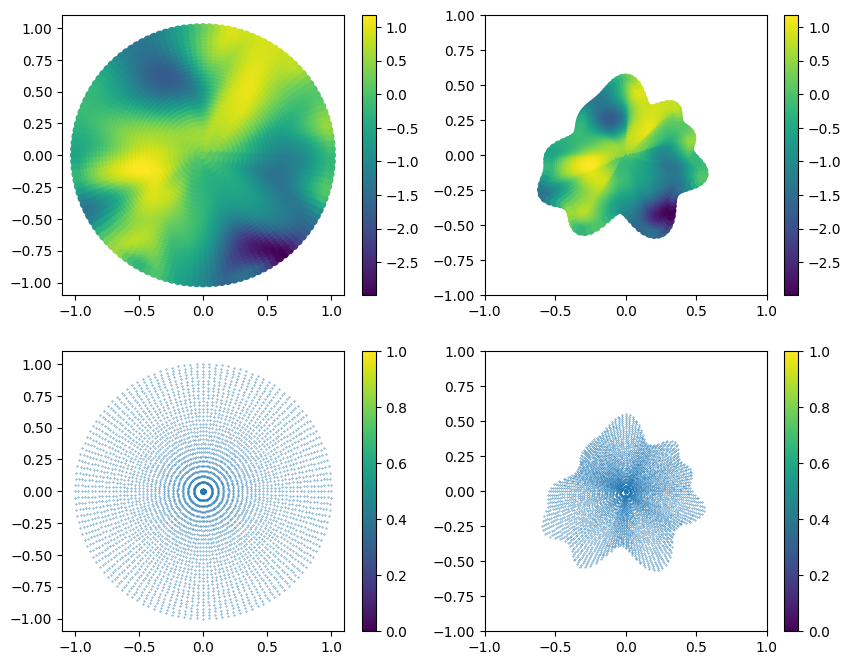

In [10]:
index = -2

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
# plt.title('predict')

plt.scatter(x_0[index,:,0],x_0[index,:,1],c = u_area[index,:,0])
# plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.colorbar()


plt.subplot(2,2,2)
# plt.title('ref')
plt.scatter(x_1[index,:,0],x_1[index,:,1],c = u_area[index,:,0])
# plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.xlim([-1,1])
plt.ylim([-1,1])
plt.colorbar()

plt.subplot(2,2,3)
# plt.title('predict')

plt.scatter(x_0[index,:,0],x_0[index,:,1],s=0.1)
# plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.colorbar()


plt.subplot(2,2,4)
# plt.title('ref')
plt.scatter(x_1[index,:,0],x_1[index,:,1],s=0.1)
# plt.plot(cond[index,:,0],cond[index,:,1],'r')
plt.xlim([-1,1])
plt.ylim([-1,1])

plt.colorbar()

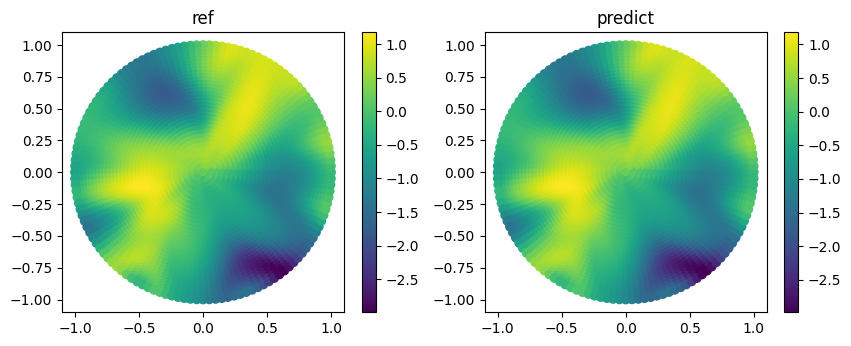

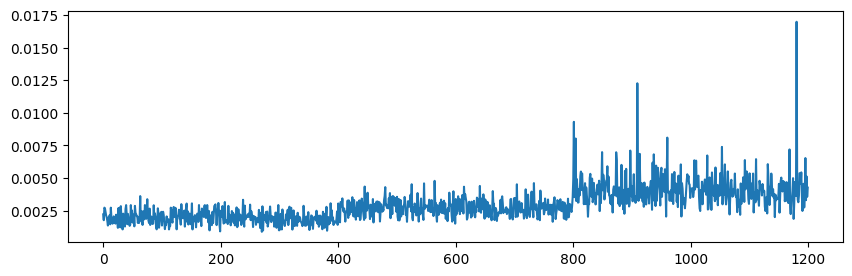

In [11]:
basis = Encoder.apply({"params": Encoder_params}, x_0[0], method = Encoder.get_trunk_net_output)
u_predict = jnp.einsum('bd,sd->bs',k_uin, basis)/jnp.sqrt(config.N_basis)

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.title('ref')
plt.scatter(x_0[index,:,0],x_0[index,:,1],c = u_area[index,:,0])
# plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.colorbar()


plt.subplot(2,2,2)
plt.title('predict')
plt.scatter(x_0[index,:,0],x_0[index,:,1],c = u_predict[index,:])
# plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.colorbar()

E = jax.vmap(RL2E,in_axes=(0,0))(u_predict,u_area[...,0])
plt.figure(figsize=(10,3))
plt.plot(E)

In [12]:
###########################################################################################################################
key, subkey = jax.random.split(key)
cond, k_fin, k_uin, u_area, f_area, x_0, x_1 = Sample_list(subkey)
###########################################################################################################################


output_dim = 512
model_dim = 256

model = TransformerModel(
    dim = model_dim,
    num_heads = 8,
    mlp_dim = model_dim*4,
    num_layers = 4,
    out_dim = output_dim
)



epochs = 200000
# epochs = 100000


key, subkey = jax.random.split(key)
params = model.init(subkey, k_fin, cond)  # 初始化参数

# with open("Transformer2.msgpack", "rb") as f:
#     params = serialization.from_bytes(params, f.read())  # 第二个参数是 bytes，返回结构匹配第一个参数的类型

# params = state.params

learning_rate_schedule = optax.cosine_decay_schedule(
    init_value = 1e-3,
    decay_steps=epochs,
    alpha= 1e-4   # 最小 lr = alpha * init_value
)
tx = optax.adam(learning_rate_schedule)
state = TrainState.create(apply_fn=model.apply, params=params, tx=tx)

    
loss_history = []

In [ ]:
# 训练起始时间
start_time = time.time()

# 保存最近10轮的总耗时和 sample 耗时
recent_epoch_times = []
recent_sample_times = []

sample_total_time = 0.0  # 累计 sample 总耗时
recent_max_len = 10      # 最近轮数，用于滑动平均

for epoch in range(epochs):
    epoch_start = time.time()

    # 记录 sample 耗时
    sample_start = time.time()
    ###########################################################################################################################
    key, subkey = jax.random.split(key)
    cond, k_fin, k_uin, u_area, f_area, x_0, x_1 = Sample_list(subkey)
    ###########################################################################################################################
    sample_times = time.time() - sample_start
    sample_total_time += sample_times

    # 保存最近的 sample 耗时
    recent_sample_times.append(sample_times)
    if len(recent_sample_times) > recent_max_len:
        recent_sample_times.pop(0)

    state, loss = train_step(state, k_fin, cond, k_uin)

    # 本轮总耗时
    epoch_time = time.time() - epoch_start
    recent_epoch_times.append(epoch_time)
    if len(recent_epoch_times) > recent_max_len:
        recent_epoch_times.pop(0)
        
    # 每 10 次迭代记录一次信息
    if epoch % 10 == 0:
        elapsed_time = time.time() - start_time  # 已用总时间
        avg_recent_time = sum(recent_epoch_times) / len(recent_epoch_times)  # 最近平均耗时
        estimated_remaining_time = avg_recent_time * (epochs - epoch - 1)  # 预计剩余时间

        # 最近平均 sample 占比
        avg_sample_time = sum(recent_sample_times) / len(recent_sample_times)
        sample_ratio = avg_sample_time / avg_recent_time * 100  # %

        #计算相对L2误差
        # RL2E = eval_step(state,x_eval,y_eval)
        loss_history.append([epoch, loss])  # 记录损失值
        
        
    # 每 500 次迭代打印一次信息
    if epoch % 500 == 0:
        # cur_lr = state.tx.optimizer.state[0].hyperparams['learning_rate']

        print(f"Epoch [{epoch}/{epochs}], "
              f"Loss: {loss:.3e}, " 
              # f"Lr: {cur_lr:.3e}, " 
              # f"RL2 Error: {RL2E:.3e}, " 
              f"Lr: {learning_rate_schedule(state.step):.1e}, "
              f"Time: {elapsed_time:.2f}s/{estimated_remaining_time:.2f}s, "
              f"Sample Ratio: {sample_ratio:.1f}%")

    # 每 50000 保存一次
    if epoch % 50000 == 0 and epoch > epochs//2:
        # 保存
        with open(str(epoch)+"Transformer.msgpack", "wb") as f:
            f.write(serialization.to_bytes(state.params))  # params 是一个 PyTree，一般是 dict

# 打印总耗时
total_time = time.time() - start_time 
print(f"Training complete! Total Time: {total_time:.2f}s, "
      f"Total Sample Time: {sample_total_time:.2f}s, "
      f"Sample Ratio: {sample_total_time/total_time*100:.1f}%")

loss_history_jnp = jnp.array(loss_history)

In [ ]:
# cond, k_fin, k_uin, u_area, f_area, x_0, x_1 = sample(key, jnp.array([7,7]))
# state, loss = train_step(state, k_fin, cond, k_uin)
# loss

In [ ]:
# loss_history_jnp[-1]

In [ ]:
# loss_history_jnp = jnp.array(loss_history)
# plt.plot(loss_history_jnp[:,0],loss_history_jnp[:,1])
# plt.yscale('log') 

In [ ]:
with open("Transformer.msgpack", "wb") as f:
    f.write(serialization.to_bytes(state.params))  # params 是一个 PyTree，一般是 dict

In [ ]:
def rounded_polygon_r(theta, angle_offset, k=6, r0=1.0, sharpness=20):
    """
    极坐标下圆角正k边形的半径函数。
    
    参数：
        theta: 极角 (numpy 数组)，单位为弧度
        k: 边数
        r0: 平均半径
        sharpness: 控制角的圆润程度，越大越尖锐
        
    返回：
        r: 每个 theta 对应的半径
    """
    theta = theta[...,0] - angle_offset
    angle = jnp.pi / k
    return (r0 * (jnp.cos(jnp.pi / k) / jnp.cos((theta % (2*jnp.pi / k)) - angle))**(1/sharpness))[None,...].repeat(config.Sample_size,0)
    
def get_Boundary_T(subkey, sigma_B, theta, thetaP, N_type=None):


    if N_type == None:
        r = get_r(subkey, sigma_B, theta)
        rP = get_r(subkey, sigma_B, thetaP)
        
    elif N_type == 0:
        r = get_r(subkey,sigma_B,theta)*0+0.6
        rP = get_r(subkey,sigma_B,thetaP)*0+0.6

    else:
        # r = rounded_polygon_r(theta, angle_offset=jnp.pi/12, k=N_type, r0=1.0, sharpness=0.25)*0.6
        # rP = rounded_polygon_r(thetaP, angle_offset=jnp.pi/12, k=N_type, r0=1.0, sharpness=0.25)*0.6

        r = rounded_polygon_r(theta, angle_offset=jnp.pi/12, k=N_type, r0=1.0, sharpness=1)*0.6
        rP = rounded_polygon_r(thetaP, angle_offset=jnp.pi/12, k=N_type, r0=1.0, sharpness=1)*0.6
    
    xx = jnp.cos(theta[...,0])*r
    yy = jnp.sin(theta[...,0])*r
    x_B = jnp.stack([xx,yy],-1)

    xxP = jnp.cos(thetaP[...,0])*rP
    yyP = jnp.sin(thetaP[...,0])*rP
    x_BP = jnp.stack([xxP,yyP],-1)

    return r,x_B,x_BP

In [ ]:
LB = 1/3
sigma_B_T = 1/LB

key, subkey = jax.random.split(key)
r,x_B,x_BP = get_Boundary_T(subkey, sigma_B_T, theta, thetaP, 5)

r0 = jnp.linspace(0.005,1,32)[:,None]**(0.8)
xx0 = jnp.cos(theta[...,0])*r0
yy0 = jnp.sin(theta[...,0])*r0
x_0 = jnp.stack([xx0,yy0],-1).reshape(-1,2)[None,...].repeat(config.Sample_size,0)

xx1 = jnp.cos(theta[...,0])*r0*r[:,None,:]
yy1 = jnp.sin(theta[...,0])*r0*r[:,None,:]
x_1 = jnp.stack([xx1,yy1],-1).reshape(config.Sample_size,-1,2)


L_u_T = 0.2
L_f_T = 0.2

key, subkey = jax.random.split(key)
u_B, _ = func(G_func(subkey, config.sigma[0]*0+1/L_u_T, x_B, sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1), config.function_K, config.function)
u_area, f_area = func(G_func(subkey, config.sigma[0]*0+1/L_u_T, x_1, sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1), config.function_K, config.function)

#--------------------------------------
key, subkey = jax.random.split(key)
f_area, _ = func(G_func(subkey, config.sigma[0]*0+1/L_f_T, x_1, sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1), config.function_K, config.function)
# f_area = f_area*0.+1
# u_B = u_B*0
#--------------------------------------


k_uin = Encoder.apply({"params": Encoder_params}, jnp.dot(u_area[...,0], pod_modes), method = Encoder.get_branch_net_output)
k_fin = Encoder.apply({"params": Encoder_params}, jnp.dot(f_area[...,0], pod_modes), method = Encoder.get_branch_net_output)

cond = jnp.concatenate([x_B,u_B],-1)

cond = cond.reshape(cond.shape[0], cond_len, -1)
k_fin = k_fin.reshape(k_fin.shape[0], seq_len, -1)


k_predict = model.apply({"params": state.params["params"]}, k_fin, cond)
basis = Encoder.apply({"params": Encoder_params}, x_0[0], method = Encoder.get_trunk_net_output)
u_predict = jnp.einsum('bd,sd->bs',k_predict, basis)/jnp.sqrt(config.N_basis)

plt.figure(figsize=(3,3))
plt.plot(x_BP[0,:,0],x_BP[0,:,1],'r')

In [ ]:
import scipy.io
from scipy.io import loadmat
from scipy.interpolate import LinearNDInterpolator, CloughTocher2DInterpolator

B = cond.reshape(config.Sample_size,-1,3)[...,:2]
u_B= cond.reshape(config.Sample_size,-1,3)[...,-1:]


scipy.io.savemat("test.mat",
{
    "x": x_1,
    "x_B": B,
    "x_BP": x_BP,
    "u_B": u_B,
    "f_source": f_area.reshape(f_area.shape[0],-1),
    "u_predict": u_predict.reshape(u_predict.shape[0],-1),
    "u_reference": u_area.reshape(u_area.shape[0],-1),
})

In [ ]:
import matlab.engine
# 检查是否已经存在 eng 变量，防止重复启动
if 'eng' not in globals():
    print("🚀 全局 MATLAB 引擎首次启动中...")
    eng = matlab.engine.start_matlab()
    print("✅ 引擎就绪！")
else:
    print("⚡ 引擎已经在线，无需重复启动。")

In [ ]:
mean_err, max_err, min_err = eng.evaluate_pde_error('test.mat', 'data/I', 1000, True, nargout=3)
# mean_err, max_err, min_err = eng.evaluate_pde_error('test.mat', 'data/I', 400, nargout=3)

In [ ]:
f_list = [0.15,0.2,0.3,0.5,'c1','c0','AD']
u_list = [0.15,0.2,0.3,0.5,'c0']


for iiu in u_list:
    
    # 1. 构造行表头 (Row Header)
    if iiu == 'c0':
        row_header = "$b=0$"
    else:
        row_header = f"$b$(l={iiu})"
    
    print(f"{row_header:<12}", end=' ')

    
    for iif in f_list:


        LB = 1/3
        sigma_B_T = 1/LB
        
        key, subkey = jax.random.split(key)
        r,x_B,x_BP = get_Boundary_T(subkey, sigma_B_T, theta, thetaP)
        
        r0 = jnp.linspace(0.005,1,32)[:,None]**(0.8)
        xx0 = jnp.cos(theta[...,0])*r0
        yy0 = jnp.sin(theta[...,0])*r0
        x_0 = jnp.stack([xx0,yy0],-1).reshape(-1,2)[None,...].repeat(config.Sample_size,0)
        
        xx1 = jnp.cos(theta[...,0])*r0*r[:,None,:]
        yy1 = jnp.sin(theta[...,0])*r0*r[:,None,:]
        x_1 = jnp.stack([xx1,yy1],-1).reshape(config.Sample_size,-1,2)

        
        L_u_T = iiu
        L_f_T = iif

        if iif == 'c0':
            L_f_T = 1
        
        if iif == 'c1':
            L_f_T = 1

        if iiu == 'c0':
            L_u_T = 1
            if iif == 'AD' or iif == 'c0':
                print(r"& \texttt{NaN}", end=' ')
                continue
            
        key, subkey = jax.random.split(key)
        u_B, _ = func(G_func(subkey, config.sigma[0]*0+1/L_u_T, x_B, sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1), config.function_K, config.function)
        u_area, f_area = func(G_func(subkey, config.sigma[0]*0+1/L_u_T, x_1, sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1), config.function_K, config.function)
        
        #--------------------------------------
        if iif != 'AD':
            key, subkey = jax.random.split(key)
            f_area, _ = func(G_func(subkey, config.sigma[0]*0+1/L_f_T, x_1, sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1), config.function_K, config.function)
        
        if iif == 'c0':
            f_area = f_area*0.+0
        
        if iif == 'c1':
            f_area = f_area*0.+1

        if iiu == 'c0':
            u_B = u_B*0
            
    
        # f_area = f_area*0.+1
        # u_B = u_B*0
        #--------------------------------------
        
        
        k_uin = Encoder.apply({"params": Encoder_params}, jnp.dot(u_area[...,0], pod_modes), method = Encoder.get_branch_net_output)
        k_fin = Encoder.apply({"params": Encoder_params}, jnp.dot(f_area[...,0], pod_modes), method = Encoder.get_branch_net_output)
        
        cond = jnp.concatenate([x_B,u_B],-1)
        
        cond = cond.reshape(cond.shape[0], cond_len, -1)
        k_fin = k_fin.reshape(k_fin.shape[0], seq_len, -1)
        
        
        k_predict = model.apply({"params": state.params["params"]}, k_fin, cond)
        basis = Encoder.apply({"params": Encoder_params}, x_0[0], method = Encoder.get_trunk_net_output)
        u_predict = jnp.einsum('bd,sd->bs',k_predict, basis)/jnp.sqrt(config.N_basis)

        B = cond.reshape(config.Sample_size,-1,3)[...,:2]
        u_B= cond.reshape(config.Sample_size,-1,3)[...,-1:]
        
        
        scipy.io.savemat("test.mat",
        {
            "x": x_1,
            "x_B": B,
            "x_BP": x_BP,
            "u_B": u_B,
            "f_source": f_area.reshape(f_area.shape[0],-1),
            "u_predict": u_predict.reshape(u_predict.shape[0],-1),
            "u_reference": u_area.reshape(u_area.shape[0],-1),
        })
        
        time.sleep(1.0)

        mean_err, max_err, min_err = eng.evaluate_pde_error('test.mat', 'data/I', 1000, nargout=3)

        print(f"& {mean_err*100:.2f}\%", end=' ')
    print(r'\\', end=' ')
    print()